In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro, kruskal, mannwhitneyu

([Swap(5), Reversion(4), Insertion(3), Slide(2)])

([ETN(6), RS(6), SPS(5), SRPS(2)])

([MinMaxSwap(5), SourceDepotSwap(2, data), ENS(1)])

In [3]:
def plot_boxplots(filename, title):
    data = np.load(filename)
    outer_array = data[data.files[0]] 

    plt.figure()
    plt.title(f"{title}")
    plt.boxplot(outer_array.T, notch=True)
    plt.xlabel("Array Index")
    plt.ylabel("Values")
    plt.show()

In [4]:
# Deterministic
filename = 'FX_values_0.npz'
data = np.load(filename)
data = data["FX_values_"]
a0 = data[0, :]
b0 = data[1, :]
c0 = data[2, :]

# Stochastic
filename = 'FX_values_1.npz'
data = np.load(filename)
data = data["FX_values_"]
a1 = data[0, :]
b1 = data[1, :]
c1 = data[2, :]

## Deterministic

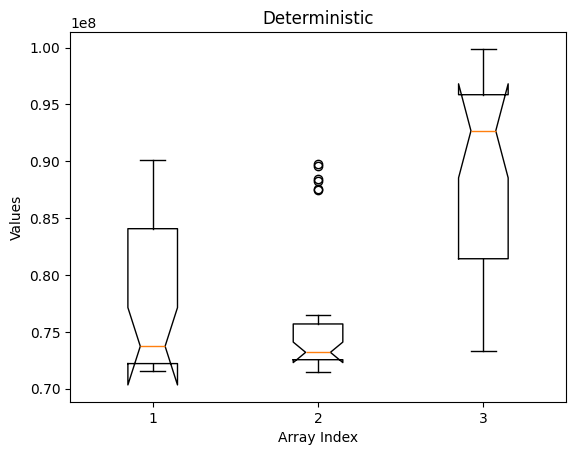

In [5]:
filename = 'FX_values_0.npz'
plot_boxplots(filename, "Deterministic")

In [6]:
print(shapiro(a0))
print(shapiro(b0))
print(shapiro(c0))

# Based on the results, none of them are normally distributed.

ShapiroResult(statistic=0.6990775238544331, pvalue=1.5127580464826659e-06)
ShapiroResult(statistic=0.6680528002222557, pvalue=5.524526330712981e-07)
ShapiroResult(statistic=0.8507287435957507, pvalue=0.0006422250911459542)


In [7]:
# perform Kruskal-Wallis test
# H0: the medians of the groups are equal

# does not assume normality

print(kruskal(a0, b0, c0))

# since H0 is rejected, the medians are not equal.

KruskalResult(statistic=39.72932844932842, pvalue=2.3598583883063202e-09)


In [8]:
# perform Mann-Whitney U test
# H0: the distribution underlying the two samples is the same

# does not assume normality

#  The alternative hypothesis is that the distribution of the first sample is stochastically 
# less than the distribution of the second sample. This means that observations in the first sample 
# tend to have smaller values than those in the second sample.

print(f"a vs b: {mannwhitneyu(a0, b0, alternative='greater')}")
print(f"a vs c: {mannwhitneyu(a0, c0, alternative='less')}")
print(f"b vs c: {mannwhitneyu(b0, c0, alternative='less')}")

a vs b: MannwhitneyuResult(statistic=481.0, pvalue=0.32602181120031787)
a vs c: MannwhitneyuResult(statistic=91.0, pvalue=5.783271602934641e-08)
b vs c: MannwhitneyuResult(statistic=74.0, pvalue=1.4157243799198181e-08)


- There is no significant difference between the distributions of a and b.

- The values in a tend to be smaller than those in c.

- The values in b tend to be smaller than those in c.

## Stochastic

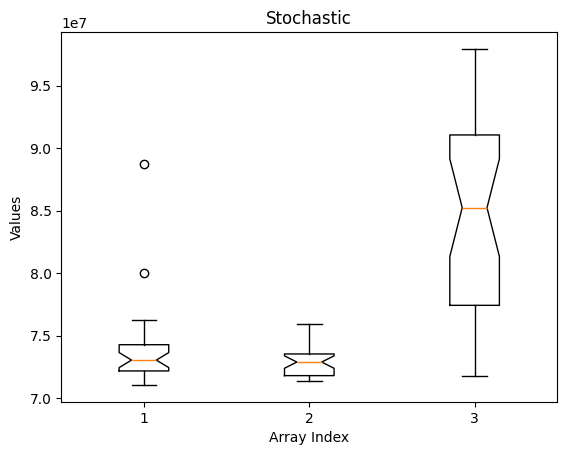

In [9]:
filename = 'FX_values_1.npz'
plot_boxplots(filename, "Stochastic")

In [10]:
print(shapiro(a0))
print(shapiro(b0))
print(shapiro(c0))

# Based on the results, none of them are normally distributed.

ShapiroResult(statistic=0.6990775238544331, pvalue=1.5127580464826659e-06)
ShapiroResult(statistic=0.6680528002222557, pvalue=5.524526330712981e-07)
ShapiroResult(statistic=0.8507287435957507, pvalue=0.0006422250911459542)


In [11]:
# perform Kruskal-Wallis test
# H0: the medians of the groups are equal

# does not assume normality

print(kruskal(a0, b0, c0))

# since H0 is rejected, the medians are not equal.

KruskalResult(statistic=39.72932844932842, pvalue=2.3598583883063202e-09)


In [12]:
# perform Mann-Whitney U test
# H0: the distribution underlying the two samples is the same

# does not assume normality

#  The alternative hypothesis is that the distribution of the first sample is stochastically 
# less than the distribution of the second sample. This means that observations in the first sample 
# tend to have smaller values than those in the second sample.

print(f"a vs b: {mannwhitneyu(a0, b0, alternative='greater')}")
print(f"a vs c: {mannwhitneyu(a0, c0, alternative='less')}")
print(f"b vs c: {mannwhitneyu(b0, c0, alternative='less')}")

a vs b: MannwhitneyuResult(statistic=481.0, pvalue=0.32602181120031787)
a vs c: MannwhitneyuResult(statistic=91.0, pvalue=5.783271602934641e-08)
b vs c: MannwhitneyuResult(statistic=74.0, pvalue=1.4157243799198181e-08)


- There is no significant difference between the distributions of a and b.

- The values in a are generally smaller than those in c.

- The values in b are generally smaller than those in c.

# Deterministic x Stochastic

In [13]:
# H0: the medians of the groups are equal

print(kruskal(a0, a1))
print(kruskal(b0, b1))
print(kruskal(c0, c1))

# There is a significant difference between the samples in group C, but
# not in A and B.

KruskalResult(statistic=1.93136612021857, pvalue=0.1646090619494458)
KruskalResult(statistic=2.3641530054644875, pvalue=0.12415128109149239)
KruskalResult(statistic=7.725464480874308, pvalue=0.005444735082163395)


In [15]:
print(f"c0 vs c1: {mannwhitneyu(c0, c1, alternative='greater')}")

# no difference between A0 and A1

c0 vs c1: MannwhitneyuResult(statistic=638.0, pvalue=0.002784969293680272)


Observations in c0 generally have higher values than those in c1.